In [28]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt

# Authenticate and initialize
ee.Authenticate()
ee.Initialize(project='fire-seasons')

In [24]:
# PARAMETERS ------------------------------------------------------------------------------------

FIRE_MASK_MIN   = 8     # >= 8 = nominal + high confidence only
ONSET_THRESHOLD = 0.05  # 5% cumulative detections = onset
END_THRESHOLD   = 0.95  # 95% cumulative detections = end of season
MIN_DETECTIONS  = 20    # minimum annual detections to compute metrics

In [25]:
# LOAD TERRA + AQUA collections --------------------------------------------------------------------

izmir = ee.Geometry.Rectangle([26.5, 37.8, 28.5, 39.0])
eco_geometry = izmir

terra = ee.ImageCollection("MODIS/061/MOD14A1") \
          .select('FireMask') \
          .filterBounds(eco_geometry)

aqua  = ee.ImageCollection("MODIS/061/MYD14A1") \
          .select('FireMask') \
          .filterBounds(eco_geometry)

print('Terra image count:', terra.size().getInfo())
print('Aqua image count:', aqua.size().getInfo())

Terra image count: 9431
Aqua image count: 8611


In [26]:
# Function: get daily detection counts for one year ------------------------------------------------

def get_daily_counts(eco_geometry, year):
    
    start  = ee.Date.fromYMD(year, 1, 1)
    n_days = 366 if year % 4 == 0 else 365

    # A fallback empty image — all zeros, one band named 'FireMask'
    # Used when a sensor has no image for a given day
    empty = ee.Image.constant(0).rename('FireMask').toUint8()

    daily_counts = []

    for d in range(150, 270): # DONT FORGET HERE SUMMER ONLY NOW
        date     = start.advance(d, 'day')
        date_end = date.advance(1, 'day')

        # Filter each sensor to this day
        terra_day = terra.filterDate(date, date_end)
        aqua_day  = aqua.filterDate(date, date_end)

        # If the collection is empty for this day, use the fallback empty image
        t = ee.Image(ee.Algorithms.If(
            terra_day.size().gt(0),
            terra_day.select('FireMask').max(),
            empty
        ))

        a = ee.Image(ee.Algorithms.If(
            aqua_day.size().gt(0),
            aqua_day.select('FireMask').max(),
            empty
        ))

        # Pixel-wise max across sensors = deduplication
        combined    = t.max(a)
        fire_binary = combined.gte(FIRE_MASK_MIN).unmask(0).rename('fire')

        count = fire_binary.reduceRegion(
            reducer   = ee.Reducer.sum(),
            geometry  = eco_geometry,
            scale     = 1000,
            maxPixels = 1e8
        ).get('fire').getInfo()

        daily_counts.append({
            'doy'          : d + 1,
            'n_detections' : int(count) if count is not None else 0
        })

    return pd.DataFrame(daily_counts)

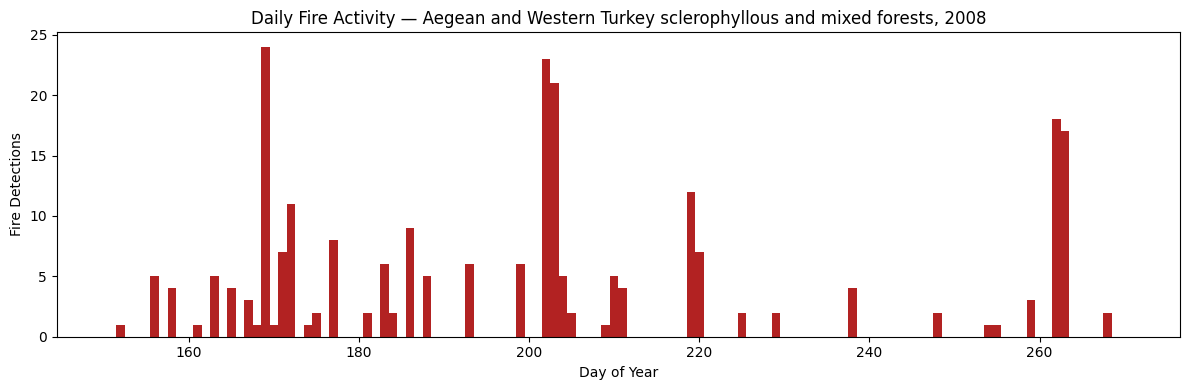

Total detections: 246
Peak DOY: 169


In [29]:
# Run for one test year and plot -------------------------------------------------------------------
TEST_YEAR = 2008

df_2008 = get_daily_counts(eco_geometry, TEST_YEAR)

plt.figure(figsize=(12, 4))
plt.bar(df_2008['doy'], df_2008['n_detections'], color='firebrick', width=1)
plt.xlabel('Day of Year')
plt.ylabel('Fire Detections')
plt.title(f'Daily Fire Activity — {ECO_NAME}, {TEST_YEAR}')
plt.tight_layout()
plt.show()

print('Total detections:', df_2008['n_detections'].sum())
print('Peak DOY:', df_2008.loc[df_2008['n_detections'].idxmax(), 'doy'])


In [30]:
# Function: compute timing metrics from daily counts -----------------------------------------------
def compute_timing_metrics(df, year):
    """
    Given a daily counts DataFrame for one ecoregion-year,
    returns a dict with onset_doy, peak_doy, end_doy, season_length.
    Returns None if total detections fall below MIN_DETECTIONS.
    """
    total = df['n_detections'].sum()

    if total < MIN_DETECTIONS:
        print(f'{year}: insufficient detections ({total}), skipping.')
        return None

    df = df.copy().sort_values('doy')
    cumulative = df['n_detections'].cumsum()
    cum_frac   = cumulative / total

    # Onset: first doy where cumulative fraction crosses 5%
    onset_rows = df[cum_frac >= ONSET_THRESHOLD]
    # End: first doy where cumulative fraction crosses 95%
    end_rows   = df[cum_frac >= END_THRESHOLD]

    if onset_rows.empty or end_rows.empty:
        print(f'{year}: could not compute onset or end, skipping.')
        return None

    # Peak: doy of maximum 7-day rolling mean
    df['rolling'] = df['n_detections'].rolling(7, center=True, min_periods=1).mean()
    peak_doy      = int(df.loc[df['rolling'].idxmax(), 'doy'])

    onset_doy  = int(onset_rows.iloc[0]['doy'])
    end_doy    = int(end_rows.iloc[0]['doy'])
    length     = end_doy - onset_doy

    return {
        'year'         : year,
        'onset_doy'    : onset_doy,
        'peak_doy'     : peak_doy,
        'end_doy'      : end_doy,
        'season_length': length,
        'n_detections' : int(total)
    }

In [31]:
# Test timing metrics on 2008 ----------------------------------------------------------------------
metrics_2008 = compute_timing_metrics(df_2008, TEST_YEAR)
print(metrics_2008)

{'year': 2008, 'onset_doy': 163, 'peak_doy': 202, 'end_doy': 263, 'season_length': 100, 'n_detections': 246}


In [33]:
# Run all years and collect results ----------------------------------------------------------------
YEARS = list(range(2003, 2006))  # short range for prototype, extend to 2025 later

all_daily = {}
all_metrics = []

for year in YEARS:
    print(f'Processing {year}...')
    df_year = get_daily_counts(eco_geometry, year)
    all_daily[year] = df_year
    metrics = compute_timing_metrics(df_year, year)
    if metrics is not None:
        all_metrics.append(metrics)

metrics_df = pd.DataFrame(all_metrics)
print(metrics_df)

Processing 2003...
Processing 2004...
Processing 2005...
   year  onset_doy  peak_doy  end_doy  season_length  n_detections
0  2003        157       176      263            106           327
1  2004        152       183      249             97           173
2  2005        156       270      269            113           257


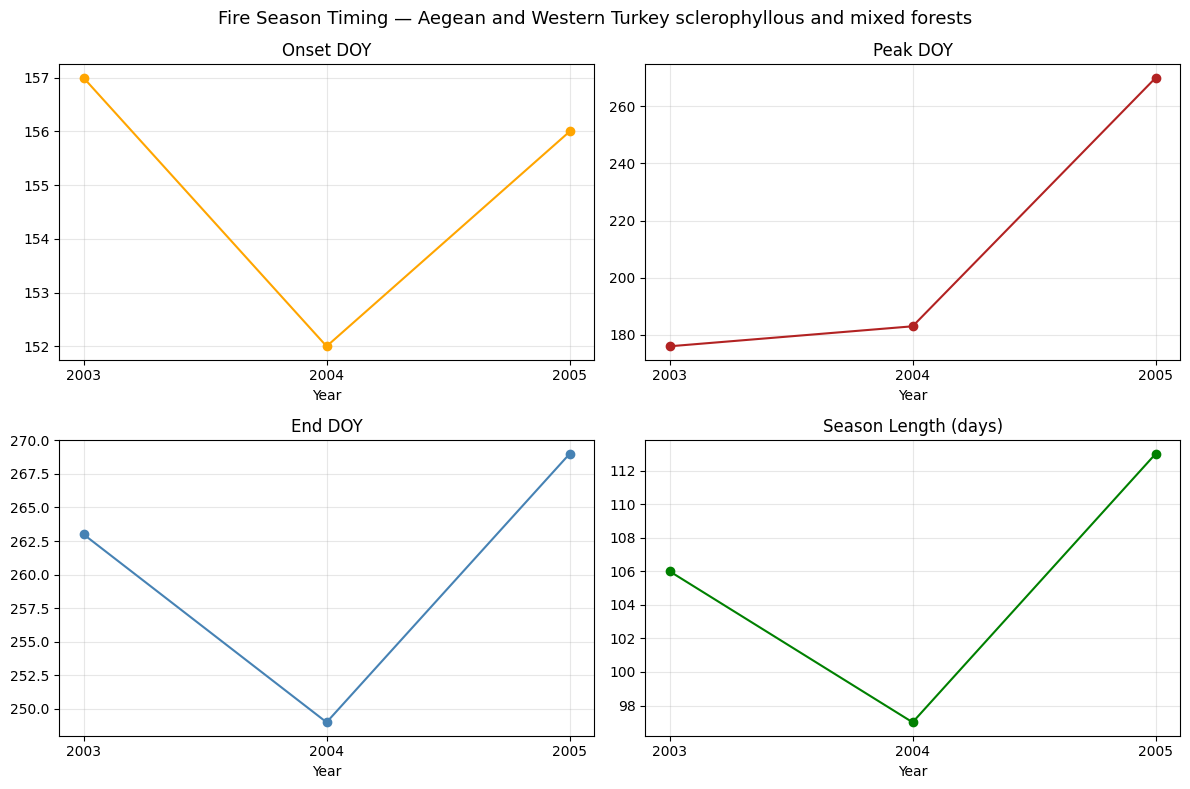

In [35]:
# Plot timing metrics across years
metrics_df['year'] = metrics_df['year'].astype(int)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(f'Fire Season Timing — {ECO_NAME}', fontsize=13)

axes[0, 0].plot(metrics_df['year'], metrics_df['onset_doy'],     marker='o', color='orange')
axes[0, 0].set_title('Onset DOY')

axes[0, 1].plot(metrics_df['year'], metrics_df['peak_doy'],      marker='o', color='firebrick')
axes[0, 1].set_title('Peak DOY')

axes[1, 0].plot(metrics_df['year'], metrics_df['end_doy'],       marker='o', color='steelblue')
axes[1, 0].set_title('End DOY')

axes[1, 1].plot(metrics_df['year'], metrics_df['season_length'], marker='o', color='green')
axes[1, 1].set_title('Season Length (days)')

for ax in axes.flatten():
    ax.set_xlabel('Year')
    ax.set_xticks(metrics_df['year'])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()